# Convolutional autoencoder for image denoising

**Author:** [Santiago L. Valdarrama](https://twitter.com/svpino)<br>
**Date created:** 2021/03/01<br>
**Last modified:** 2021/03/01<br>
**Description:** How to train a deep convolutional autoencoder for image denoising.

## Introduction

This example demonstrates how to implement a deep convolutional autoencoder
for image denoising, mapping noisy digits images from the MNIST dataset to
clean digits images. This implementation is based on an original blog post
titled [Building Autoencoders in Keras](https://blog.keras.io/building-autoencoders-in-keras.html)
by [François Chollet](https://twitter.com/fchollet).

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from keras import layers
from keras.datasets import mnist
from keras.models import Model


def preprocess(array):
    """Normalizes the supplied array and reshapes it."""
    array = array.astype("float32") / 255.0
    array = np.reshape(array, (len(array), 28, 28, 1))
    return array


def noise(array):
    """Adds random noise to each image in the supplied array."""
    noise_factor = 0.4
    noisy_array = array + noise_factor * np.random.normal(
        loc=0.0, scale=1.0, size=array.shape
    )

    return np.clip(noisy_array, 0.0, 1.0)


def display(array1, array2):
    """Displays ten random images from each array."""
    n = 10
    indices = np.random.randint(len(array1), size=n)
    images1 = array1[indices, :]
    images2 = array2[indices, :]

    plt.figure(figsize=(20, 4))
    for i, (image1, image2) in enumerate(zip(images1, images2)):
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(image1.reshape(28, 28))
        plt.gray()
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(image2.reshape(28, 28))
        plt.gray()
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

    plt.show()

## Prepare the data

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


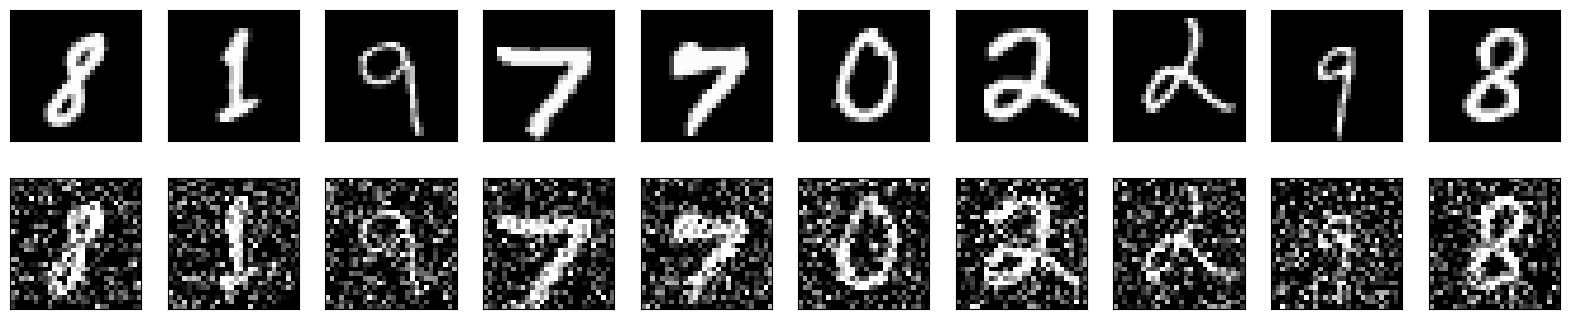

In [2]:
# Since we only need images from the dataset to encode and decode, we
# won't use the labels.
(train_data, _), (test_data, _) = mnist.load_data()

# Normalize and reshape the data
train_data = preprocess(train_data)
test_data = preprocess(test_data)

# Create a copy of the data with added noise
noisy_train_data = noise(train_data)
noisy_test_data = noise(test_data)

# Display the train data and a version of it with added noise
display(train_data, noisy_train_data)

## Build the autoencoder

We are going to use the Functional API to build our convolutional autoencoder.

In [3]:
input = layers.Input(shape=(28, 28, 1))

# Encoder
x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(input)
x = layers.MaxPooling2D((2, 2), padding="same")(x)
x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(x)
x = layers.MaxPooling2D((2, 2), padding="same")(x)

# Decoder
x = layers.Conv2DTranspose(32, (3, 3), strides=2, activation="relu", padding="same")(x)
x = layers.Conv2DTranspose(32, (3, 3), strides=2, activation="relu", padding="same")(x)
x = layers.Conv2D(1, (3, 3), activation="sigmoid", padding="same")(x)

# Autoencoder
autoencoder = Model(input, x)
autoencoder.compile(optimizer="adam", loss="binary_crossentropy")
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 32)     │         9,248 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │         9,248 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,353 (110.75 KB)

 Trainable params: 28,353 (110.75 KB)

 Non-trainable params: 0 (0.00 B)

Now we can train our autoencoder using `train_data` as both our input data
and target. Notice we are setting up the validation data using the same
format.

In [4]:
autoencoder.fit(
    x=train_data,
    y=train_data,
    epochs=50,
    batch_size=128,
    shuffle=True,
    validation_data=(test_data, test_data),
)

Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 0.1327 - val_loss: 0.0732
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0715 - val_loss: 0.0693
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0690 - val_loss: 0.0678
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0678 - val_loss: 0.0669
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0670 - val_loss: 0.0663
Epoch 6/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0664 - val_loss: 0.0657
Epoch 7/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0659 - val_loss: 0.0653
Epoch 8/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0656 - val_loss: 0.0650
Epoch 9/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0652 - val_loss: 0.0647
Epoch 10/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0650 - val_loss: 0.0644
Epoch 11/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0647 - val_loss: 0.0642
Epoch 12/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/st

Let's predict on our test dataset and display the original image together with
the prediction from our autoencoder.

Notice how the predictions are pretty close to the original images, although
not quite the same.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


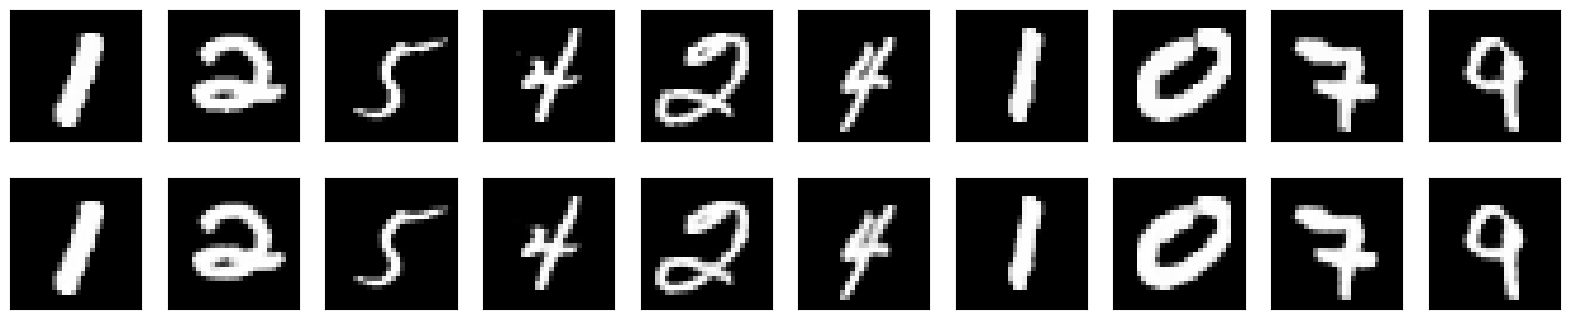

In [5]:
predictions = autoencoder.predict(test_data)
display(test_data, predictions)

Now that we know that our autoencoder works, let's retrain it using the noisy
data as our input and the clean data as our target. We want our autoencoder to
learn how to denoise the images.

In [6]:
autoencoder.fit(
    x=noisy_train_data,
    y=train_data,
    epochs=100,
    batch_size=128,
    shuffle=True,
    validation_data=(noisy_test_data, test_data),
)

Epoch 1/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1027 - val_loss: 0.0946
Epoch 2/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0940 - val_loss: 0.0924
Epoch 3/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0922 - val_loss: 0.0909
Epoch 4/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0911 - val_loss: 0.0900
Epoch 5/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0903 - val_loss: 0.0892
Epoch 6/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0897 - val_loss: 0.0887
Epoch 7/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0892 - val_loss: 0.0883
Epoch 8/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0887 - val_loss: 0.0879
Epoch 9/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0884 - val_loss: 0.0876
Epoch 10/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0881 - val_loss: 0.0873
Epoch 11/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0878 - val_loss: 0.0870
Epoch 12/100
469/469 ━━━━━━━━━━━━━━━━━━━━

Let's now predict on the noisy data and display the results of our autoencoder.

Notice how the autoencoder does an amazing job at removing the noise from the
input images.

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


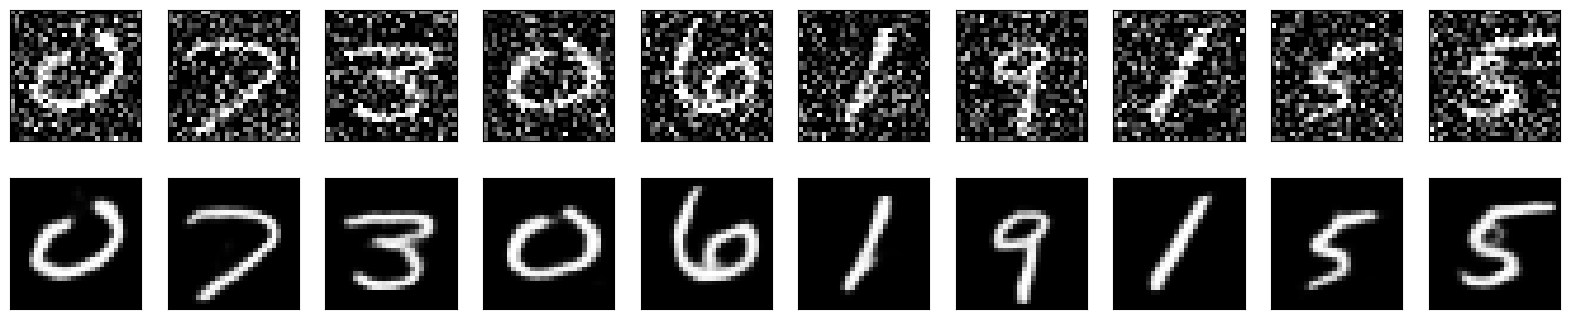

In [7]:
predictions = autoencoder.predict(noisy_test_data)
display(noisy_test_data, predictions)

array([[225, 255, 250, ..., 235, 226, 255],
       [255, 255, 212, ..., 223, 255, 223],
       [198, 230, 255, ..., 255, 169, 214],
       ...,
       [255, 235, 226, ..., 151, 168, 146],
       [255, 204, 238, ..., 185, 164, 185],
       [233, 230, 249, ..., 182, 151, 186]], dtype=uint8)
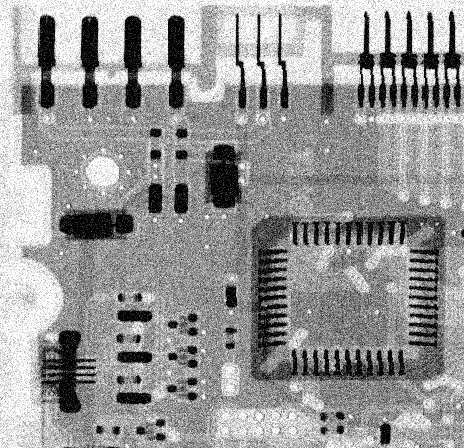

In [17]:
import cv2
I = cv2.imread('sample_data/noisy_circuit.bmp', cv2.IMREAD_GRAYSCALE)
I

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step


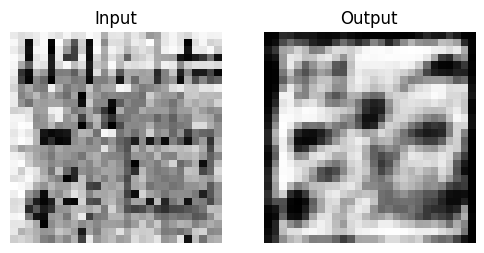

In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load grayscale image
I = cv2.imread('sample_data/noisy_circuit.bmp', cv2.IMREAD_GRAYSCALE)

if I is None:
    raise FileNotFoundError("Could not load image.")

# Resize to match autoencoder input
I_resized = cv2.resize(I, (28, 28))

# Normalize to [0,1]
I_resized = I_resized.astype('float32') / 255.0

# Add channel dimension: (28, 28) -> (28, 28, 1)
I_input = np.expand_dims(I_resized, axis=-1)

# Add batch dimension: (28, 28, 1) -> (1, 28, 28, 1)
I_input = np.expand_dims(I_input, axis=0)

# Predict
predictions = autoencoder.predict(I_input)

# Show input and output
plt.figure(figsize=(6,3))

plt.subplot(1,2,1)
plt.imshow(I_input[0, :, :, 0], cmap='gray')
plt.title("Input")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(predictions[0, :, :, 0], cmap='gray')
plt.title("Output")
plt.axis('off')

plt.show()

### Creating a synthetic noisy image from the original circuit image

We can use the `noise` function to generate a noisy version of your original circuit image (`I`). First, we'll need to normalize `I` to the 0-1 range, similar to how the MNIST data was preprocessed.

In [ ]:
I_normalized = I.astype('float32') / 255.0

# The 'noise' function expects a 4D array (batch, height, width, channels)
# Our image I_normalized is currently (height, width).
# We need to reshape it to (1, height, width, 1) for the 'noise' function.
I_input_for_noise = np.expand_dims(np.expand_dims(I_normalized, axis=-1), axis=0)

noisy_circuit_image = noise(I_input_for_noise)

# Display the original and the newly generated noisy image
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(I_normalized, cmap='gray')
plt.title('Original Clean Circuit Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(noisy_circuit_image[0, :, :, 0], cmap='gray')
plt.title('Synthetically Noisy Circuit Image')
plt.axis('off')

plt.show()

This shows how you can create a noisy version of your clean image. To train a new autoencoder for images of this size, you would typically repeat this process many times, adding different random noise each time to create a diverse training set where the input is the noisy image and the target output is always the original clean image (`I_normalized`).

However, **the crucial next step would be to build an autoencoder model with an architecture suitable for the actual dimensions of your `noisy_circuit.bmp` image, rather than 28x28.**

## Relevant Chapters from Deep Learning with Python
- [Chapter 17: Image generation](https://deeplearningwithpython.io/chapters/chapter17_image-generation)
